In [ ]:
import os
import sys
import gc
from pathlib import Path   
os.chdir('/zhome/71/c/146676/texture_tomography')
sys.path.append('/zhome/71/c/146676/texture_tomography/package/odf_mumott')
import h5py
import numpy as np

from package.texture_tomography.operators.pfo_and_projection_batched_opencl import PFO_OPENCL_BATCHED

import matplotlib.pyplot as plt
from multiprocessing import Pool
import yaml

from package.odf_mumott.odftt.texture import grids


from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_huber_opencl import FISTAHuberOpenCL
from package.texture_tomography.gpu_live_tracker import GPUMemoryLogger
from package.texture_tomography.operators.operator_memory_model import OperatorMemoryModel
from package.texture_tomography.operators.memory_tracker import MemoryCounter
from package.texture_tomography.optimization.fista_opencl import FISTAOpenCL
from package.texture_tomography.optimization.fista_memory_model import FISTAMemoryModel
from package.texture_tomography.material import Material
import pyopencl.array as clarray

from orix import plot, sampling
from orix.crystal_map import Phase
from orix.quaternion import Orientation, symmetry
from orix.vector import Vector3d

from package.texture_tomography.operators.create_pfo_matrix import pfmatrix_sparseeval_gpu,sparse_pf_innerprod_gpu,interp_theta_4d_gpu, interp_theta_3d_gpu, build_pfsparse_program, sum_over_x_gpu, clip_nonnegative_gpu
from package.texture_tomography.multiresolution_refiner import OrientationTree, OrientationNode, generate_hopf_grid_fzone, invert_grid
import pyopencl as cl
from scipy.spatial.transform import Rotation as ROT

INFO:Setting the number of threads to 8. If your physical cores are fewer than this number, you may want to use numba.set_num_threads(n), and os.environ["OPENBLAS_NUM_THREADS"] = f"{n}" to set the number of threads to the number of physical cores n.
INFO:Setting numba log level to WARNING.


In [2]:
#config_path = "configs/aluminum_config_small.yaml"
config_path = "configs/bb_config_1.yaml"

with open(config_path, 'r') as f:
    cfg = yaml.safe_load(f)

grid_resolution_parameter = cfg['grid_resolution_parameter']
kernel_sigma = cfg['kernel_sigma']
N_theta = cfg['N_theta']
min_two_theta = cfg['min_two_theta']
N_chi = cfg['N_chi']
N_rot = cfg['N_rot']
Nx = cfg['Nx']
Ny = cfg['Ny']
peak_width = cfg['peak_width']
datapath = cfg["datapath"]
absorption_file = cfg['absorption_file']
filename_integrated = cfg["integrated_file"]
cif_path = cfg["cif_path"]
#reflections_folder = cfg["reflections_folder"]
cor_offset = cfg["cor_offset"]
N_seg = N_theta*N_chi
filename = cfg['integrated_file']
wavelength_kev = cfg['wavelength']
min_two_theta = cfg['min_two_theta']
max_two_theta = cfg['max_two_theta']
reflection_cutoff = cfg['reflection_cutoff']

In [3]:
cif_folder = Path(cif_path)
filenames = [p.name for p in cif_folder.glob("*.cif")]
N_mat = len(filenames)

materials = []

for i_mat in range(N_mat):
    path = cif_folder / filenames[i_mat]
    material = Material.from_cif(
        cif_path=path,
        wavelength_kev=wavelength_kev,
        min_two_theta=min_two_theta,
        max_two_theta=max_two_theta,
        intensity_cutoff_fraction=reflection_cutoff,
    )
    materials.append(material)


In [4]:
grid_resolution_parameter = 4      # example
kernel_sigma = 0.3                # example
sigma_levels = [kernel_sigma]      # start with single level

grids = []

for mat in materials:
    tree = OrientationTree.from_hopf_fzone(
        mat.point_group_matrices,
        grid_resolution_parameter=grid_resolution_parameter,
        sigma_levels=sigma_levels,
    )
    grids.append(tree)

In [5]:
with h5py.File(datapath + absorption_file, 'r') as file:
    # Check the keys in the file (this shows the main datasets or groups)
    
    # Access a dataset or group (replace 'your_dataset' with the correct key)
    dtc= file['entry/instrument/xspress3']
    data_all_events = dtc['all_events'][:].reshape(181,362)
    data_output_count_rate = dtc['output_count_rate'][:].reshape(181,362)
    data_att = dtc['window_counts'][:][:,0].reshape(181,362)


print('Loaded shape:', data_att.shape)



N_workers = 16  # adjust to match available CPUs

# --- Get list of dataset keys (exclude metadata) ---
with h5py.File(filename, 'r') as f:
    keys = [k for k in f.keys() if k != 'two_theta']
keys = sorted(keys, key=lambda x: int(x))


# --- Worker function ---
def load_single(key):
    with h5py.File(filename, 'r') as f:
        arr = f[key][...]
    return arr

with h5py.File(filename, 'r') as f:
    two_theta = f['two_theta'][:]


# --- Parallel load ---
with Pool(processes=N_workers) as pool:
    data_list = pool.map(load_single, keys)

# --- Combine into single array ---
data = np.stack(data_list, axis=0)

print('Loaded shape:', data.shape)
data_corrected = data/data_att[:,:,None,None]*100
all_data_reshaped = data_corrected.reshape((N_rot, Nx, N_chi*N_theta))

Loaded shape: (181, 362)
Loaded shape: (181, 362, 90, 120)


[iter    1/20] obj=1.901295e+06  f=1.901295e+06  g=0.000000e+00  ||x||=7.337526e-05  ||grad||=7.337526e+06  tau=1.000e-11  beta=0.000e+00
[iter    2/20] obj=1.871078e+06  f=1.871078e+06  g=0.000000e+00  ||x||=1.429571e-04  ||grad||=6.958423e+06  tau=1.000e-11  beta=2.818e-01
[iter    3/20] obj=1.836501e+06  f=1.836501e+06  g=0.000000e+00  ||x||=2.275535e-04  ||grad||=6.500082e+06  tau=1.000e-11  beta=4.340e-01
[iter    4/20] obj=1.799931e+06  f=1.799931e+06  g=0.000000e+00  ||x||=3.240574e-04  ||grad||=5.980984e+06  tau=1.000e-11  beta=5.311e-01
[iter    5/20] obj=1.763462e+06  f=1.763462e+06  g=0.000000e+00  ||x||=4.294481e-04  ||grad||=5.419262e+06  tau=1.000e-11  beta=5.988e-01
[iter    6/20] obj=1.728826e+06  f=1.728826e+06  g=0.000000e+00  ||x||=5.407840e-04  ||grad||=4.832725e+06  tau=1.000e-11  beta=6.489e-01
[iter    7/20] obj=1.697328e+06  f=1.697328e+06  g=0.000000e+00  ||x||=6.552499e-04  ||grad||=4.238602e+06  tau=1.000e-11  beta=6.876e-01
[iter    8/20] obj=1.669816e+06  f

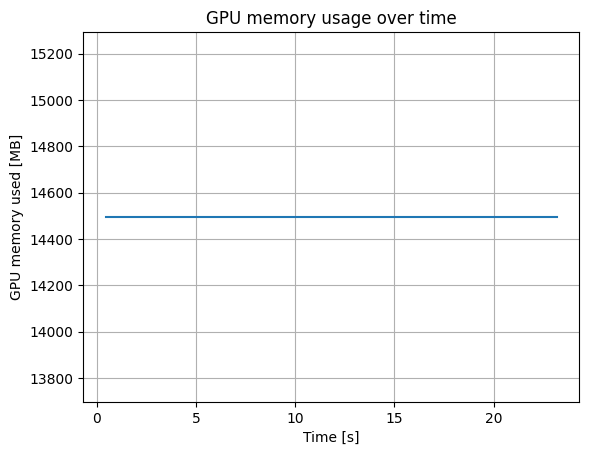

In [6]:
gpu_log = GPUMemoryLogger(interval=0.2, gpu_id=1)
gpu_log.start()

op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        materials=materials,
        grids=grids,
        two_thetas = two_theta,
        verbose=False)

queue = op.queue
Nx, Ny, K = op.Nx, op.Ny, op.K_sum

x0_gpu = clarray.zeros(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous
op.set_pf_batch_max_gb(1.5)
# l1 constant: 1e7
# tv constant: 2e-6
# L constant for l1: 5e11
solver = FISTAOpenCL(op, prox_kind="nonneg", lam=1e2, L=1e11)


x_sol_gpu = solver.run(x0_gpu, out_gpu, niter=20, verbose=1, diagnostics_interval=1)
coeffs = x_sol_gpu.get().transpose((0,1,2))[::-1,::-1]
# op.free_memory()
# del x_sol_gpu
# del out_gpu
# del x0_gpu
# gc.collect()

gpu_log.stop()

t, mem = gpu_log.as_arrays()
import matplotlib.pyplot as plt

plt.plot(t, mem)
plt.xlabel("Time [s]")
plt.ylabel("GPU memory used [MB]")
plt.title("GPU memory usage over time")
plt.grid(True)
plt.show()

In [7]:
pf_prg = build_pfsparse_program(op.ctx)
kernel_pfmatrix_count_sparse = cl.Kernel(pf_prg, "pfmatrix_count_sparse")
kernel_pfmatrix_write_sparse = cl.Kernel(pf_prg, "pfmatrix_write_sparse")
kernel_sparse_pf_innerprod_4d = cl.Kernel(pf_prg, "sparse_pf_innerprod_4d")
kernel_interp3d = cl.Kernel(pf_prg, "interp_theta_3d")
kernel_interp4d = cl.Kernel(pf_prg, "interp_theta_4d")
kernel_sum_over_x = cl.Kernel(pf_prg, "sum_over_x")
kernel_clip_nonnegative = cl.Kernel(pf_prg, "clip_nonnegative")

prediction_gpu = op.direct(x_sol_gpu)
prediction_cpu = prediction_gpu.get().reshape((N_rot, Nx, N_chi, N_theta))
res_gpu = out_gpu - prediction_gpu
clip_nonnegative_gpu(op.queue, kernel_clip_nonnegative, res_gpu)
res_gpu = res_gpu.reshape((N_rot, Nx, N_chi, N_theta))



In [8]:
def score_nodes(queue, op, node_indices, i_mat, sigma, res_peaks_gpu_summed):
    rotations = [tree.nodes[i].R for i in node_indices]
    grid_inv_cpu = invert_grid(rotations)
    grid_inv_gpu = clarray.to_device(queue, grid_inv_cpu)

    K = len(rotations)
    R = op.N_rot
    C = op.N_chi
    P = op.N_peaks_list[i_mat]
    G = len(materials[i_mat].point_group_matrices)

    cutoff = 0.1 * 1.0 / (2*np.pi*sigma**2)

    sparse_pf = pfmatrix_sparseeval_gpu(
        queue,
        kernel_pfmatrix_count_sparse,
        kernel_pfmatrix_write_sparse,
        op.pf_coords_gpu_list[i_mat],
        grid_inv_gpu,
        op.pf_sym_ops_gpu_list[i_mat],
        op.pf_h_gpu_list[i_mat],
        R, K, C, P, G,
        sigma,
        cutoff
    )

    IPs = sparse_pf_innerprod_gpu(
        queue,
        kernel_sparse_pf_innerprod_4d,
        sparse_pf,
        res_peaks_gpu_summed,
        R, C, P, K,
    )

    scores = IPs.get()
    scores = np.maximum(scores, 0)
    scores /= (scores.max() + 1e-12)

    for local_k, node_idx in enumerate(node_indices):
        tree.nodes[node_idx].score = float(scores[local_k])

    return scores


In [9]:
def refine_level(queue, op, tree, i_mat, level, res_peaks_gpu_summed=None):

    # --------------------------------------------------
    # 1. Score active leaf nodes at this level
    # --------------------------------------------------
    subgrid = tree.active_leaf_nodes_at_level(level)

    scores = score_nodes(
        queue, op,
        node_indices=subgrid,
        i_mat=i_mat,
        sigma=tree.sigma_levels[level],
        res_peaks_gpu_summed=res_peaks_gpu_summed,
    )

    # --------------------------------------------------
    # 2. Non-max suppression on SO(3)
    # --------------------------------------------------
    rotations = [tree.nodes[i].R for i in subgrid]
    delta = 1.5 * tree.sigma_levels[level]

    order = np.argsort(scores)[::-1]
    suppressed = np.zeros(len(subgrid), dtype=bool)
    selected_local = []

    for idx in order:
        if suppressed[idx]:
            continue
        if scores[idx] < 0.2:
            break

        selected_local.append(idx)
        Ri = rotations[idx]

        for j in order:
            if suppressed[j] or j == idx:
                continue
            d = np.linalg.norm((Ri.inv() * rotations[j]).as_rotvec())
            if d < delta:
                suppressed[j] = True

        if len(selected_local) >= 30:
            break

    parent_indices = [
        subgrid[i] for i in selected_local if scores[i] > 0.5
    ]

    # deactivate parents
    for p in parent_indices:
        tree.nodes[p].active = False

    # --------------------------------------------------
    # 3. Generate children
    # --------------------------------------------------
    new_children = tree.generate_children(
        parents=parent_indices,
        radius=tree.sigma_levels[level],
        stencil=12,
    )

    # --------------------------------------------------
    # 4. Score children
    # --------------------------------------------------
    child_scores = score_nodes(
        queue, op,
        node_indices=new_children,
        i_mat=i_mat,
        sigma=tree.sigma_levels[level + 1],
        res_peaks_gpu_summed=res_peaks_gpu_summed,
    )

    # --------------------------------------------------
    # 5. Prune children
    # --------------------------------------------------
    KEEP_PER_PARENT = 2
    MIN_SCORE = 0.3

    children_by_parent = {}
    for child_idx in new_children:
        p = tree.nodes[child_idx].parent
        children_by_parent.setdefault(p, []).append(child_idx)

    for parent, kids in children_by_parent.items():
        kids_sorted = sorted(
            kids, key=lambda i: tree.nodes[i].score, reverse=True
        )

        for i, k in enumerate(kids_sorted):
            tree.nodes[k].active = (
                i < KEEP_PER_PARENT and tree.nodes[k].score > MIN_SCORE
            )


In [10]:
grid_resolution_parameter = 5      # example
kernel_sigma = 0.3                # example
sigma_levels = [kernel_sigma, kernel_sigma/2, kernel_sigma/4, kernel_sigma/8]      # start with single level

grids = []

for mat in materials:
    tree = OrientationTree.from_hopf_fzone(
        mat.point_group_matrices,
        grid_resolution_parameter=grid_resolution_parameter,
        sigma_levels=sigma_levels,
    )
    grids.append(tree)

In [11]:
for i_mat in range(N_mat):
    theta_grid_gpu = clarray.to_device(op.queue, op.two_thetas)
    theta_peaks_gpu = clarray.to_device(op.queue, op.peak_positions_np_list[i_mat])

    res_peaks_gpu = clarray.empty(queue, (op.N_rot, op.Nx, op.N_chi, op.N_peaks_list[i_mat]), dtype=np.float32, order="C")


    interp_theta_4d_gpu(
        op.queue,
        kernel_interp4d,
        res_gpu,
        res_peaks_gpu,
        theta_grid_gpu,
        theta_peaks_gpu,
        op.N_rot, op.Nx, op.N_chi, op.N_theta, op.N_peaks_list[i_mat],
    )

    res_peaks_gpu_summed = clarray.empty(queue, (op.N_rot, op.N_chi, op.N_peaks_list[i_mat]), dtype=np.float32, order="C")

    sum_over_x_gpu(op.queue, kernel_sum_over_x, res_peaks_gpu, res_peaks_gpu_summed, op.N_rot, op.Nx, op.N_chi, op.N_peaks_list[i_mat])
    res_peaks_cpu = res_peaks_gpu_summed.get()
    res_peaks_cpu = res_peaks_cpu - res_peaks_cpu.mean(axis=1, keepdims=True)
    res_peaks_cpu = np.clip(res_peaks_cpu, a_min=0, a_max = 10000000)

    res_peaks_gpu_summed = clarray.to_device(op.queue, np.ascontiguousarray(res_peaks_cpu, dtype=np.float32))
    tree = grids[i_mat]

    refine_level(op.queue, op, tree, i_mat, 0, res_peaks_gpu_summed=res_peaks_gpu_summed)
    refine_level(op.queue, op, tree, i_mat, 1, res_peaks_gpu_summed=res_peaks_gpu_summed)
    refine_level(op.queue, op, tree, i_mat, 2, res_peaks_gpu_summed=res_peaks_gpu_summed)


In [12]:
tree.print_summary()
lvl = 2
idx = tree.active_nodes_at_level(lvl)[2]
tree.inspect_node(idx)

OrientationTree summary:
  level 0: 20 active / 50 total
  level 1: 30 active / 360 total
  level 2: 30 active / 360 total
  level 3: 60 active / 360 total


{'index': 461,
 'level': 2,
 'active': True,
 'sigma': 0.075,
 'score': 0.7965174913406372,
 'parent': 235,
 'children': [],
 'rotation_matrix': array([[ 0.20530695,  0.13785559,  0.96894009],
        [-0.72782879,  0.68338673,  0.05698973],
        [-0.65430445, -0.71692288,  0.24063931]]),
 'rotvec': array([-0.58401133,  1.22493573, -0.65326431])}

[iter    1/100] obj=3.921689e+05  f=3.921689e+05  g=0.000000e+00  ||x||=3.558962e-05  ||grad||=1.779481e+07  tau=2.000e-12  beta=0.000e+00
[iter    2/100] obj=3.676358e+05  f=3.676358e+05  g=0.000000e+00  ||x||=6.032117e-05  ||grad||=1.506712e+07  tau=2.000e-12  beta=2.818e-01
[iter    3/100] obj=3.457038e+05  f=3.457038e+05  g=0.000000e+00  ||x||=9.211219e-05  ||grad||=1.391661e+07  tau=2.000e-12  beta=4.340e-01
[iter    4/100] obj=3.269019e+05  f=3.269019e+05  g=0.000000e+00  ||x||=1.238300e-04  ||grad||=1.391037e+07  tau=2.000e-12  beta=5.311e-01
[iter    5/100] obj=3.084282e+05  f=3.084282e+05  g=0.000000e+00  ||x||=1.588206e-04  ||grad||=1.264560e+07  tau=2.000e-12  beta=5.988e-01
[iter    6/100] obj=2.937899e+05  f=2.937899e+05  g=0.000000e+00  ||x||=1.931833e-04  ||grad||=1.392877e+07  tau=2.000e-12  beta=6.489e-01
[iter    7/100] obj=2.772251e+05  f=2.772251e+05  g=0.000000e+00  ||x||=2.294785e-04  ||grad||=1.168045e+07  tau=2.000e-12  beta=6.876e-01
[iter    8/100] obj=2.65690

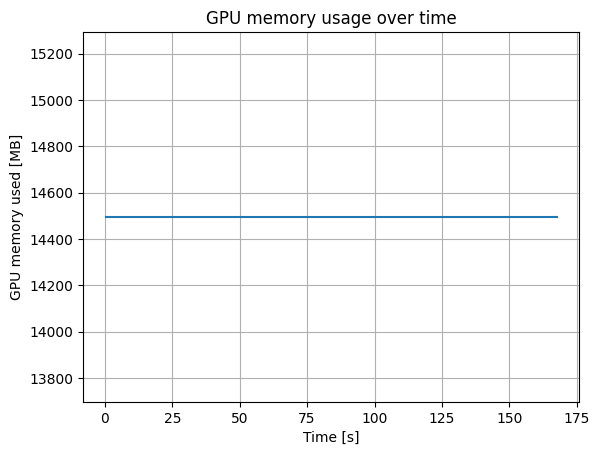

In [13]:
gpu_log = GPUMemoryLogger(interval=0.2, gpu_id=1)
gpu_log.start()

op = PFO_OPENCL_BATCHED(
        cfg = cfg,
        materials=materials,
        grids=grids,
        two_thetas = two_theta,
        verbose=False)

queue = op.queue
Nx, Ny, K = op.Nx, op.Ny, op.K_sum

x0_gpu = clarray.zeros(
    queue,
    (Nx, Ny, K),
    dtype=np.float32,
    order="F",
)

out_cpu = np.ascontiguousarray(
    all_data_reshaped,
    dtype=np.float32
)
out_gpu = clarray.to_device(queue, out_cpu)
assert out_gpu.flags.c_contiguous
op.set_pf_batch_max_gb(1.5)
# l1 constant: 1e7
# tv constant: 2e-6
# L constant for l1: 5e11
solver = FISTAHuberOpenCL(op, prox_kind="nonneg", lam=1e2, L=5e11, huber_delta=0.25)


x_sol_gpu = solver.run(x0_gpu, out_gpu, niter=100, verbose=1, diagnostics_interval=1)
coeffs = x_sol_gpu.get().transpose((0,1,2))[::-1,::-1]
# op.free_memory()
# del x_sol_gpu
# del out_gpu
# del x0_gpu
# gc.collect()

gpu_log.stop()

t, mem = gpu_log.as_arrays()
import matplotlib.pyplot as plt

plt.plot(t, mem)
plt.xlabel("Time [s]")
plt.ylabel("GPU memory used [MB]")
plt.title("GPU memory usage over time")
plt.grid(True)
plt.show()

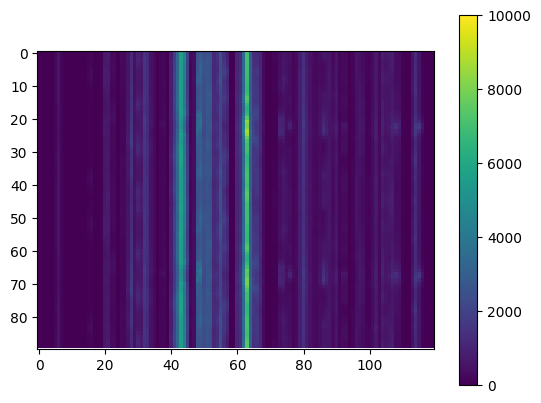

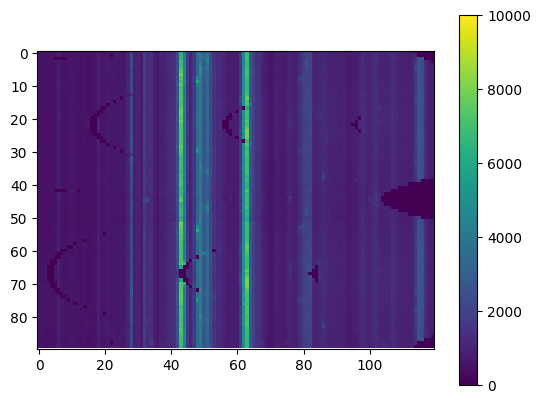

In [14]:
pf_prg = build_pfsparse_program(op.ctx)
kernel_pfmatrix_count_sparse = cl.Kernel(pf_prg, "pfmatrix_count_sparse")
kernel_pfmatrix_write_sparse = cl.Kernel(pf_prg, "pfmatrix_write_sparse")
kernel_sparse_pf_innerprod_4d = cl.Kernel(pf_prg, "sparse_pf_innerprod_4d")
kernel_interp3d = cl.Kernel(pf_prg, "interp_theta_3d")
kernel_interp4d = cl.Kernel(pf_prg, "interp_theta_4d")
kernel_sum_over_x = cl.Kernel(pf_prg, "sum_over_x")
kernel_clip_nonnegative = cl.Kernel(pf_prg, "clip_nonnegative")

prediction_gpu = op.direct(x_sol_gpu)
prediction_cpu = prediction_gpu.get().reshape((N_rot, Nx, N_chi, N_theta))
res_gpu = out_gpu - prediction_gpu
clip_nonnegative_gpu(op.queue, kernel_clip_nonnegative, res_gpu)
res_gpu = res_gpu.reshape((N_rot, Nx, N_chi, N_theta))

plt.imshow(prediction_cpu[:,:].sum(axis=(0,1)))
plt.colorbar()
plt.clim([0,50000*0.2])
plt.show()

plt.imshow(data_corrected[:,:].sum(axis=(0,1)))
plt.colorbar()
plt.clim([0,50000*0.2])
plt.show()

(362, 80, 3249)
[ 99 319 184 190 318 139 319 209 590 126 209 209  98 100 140]


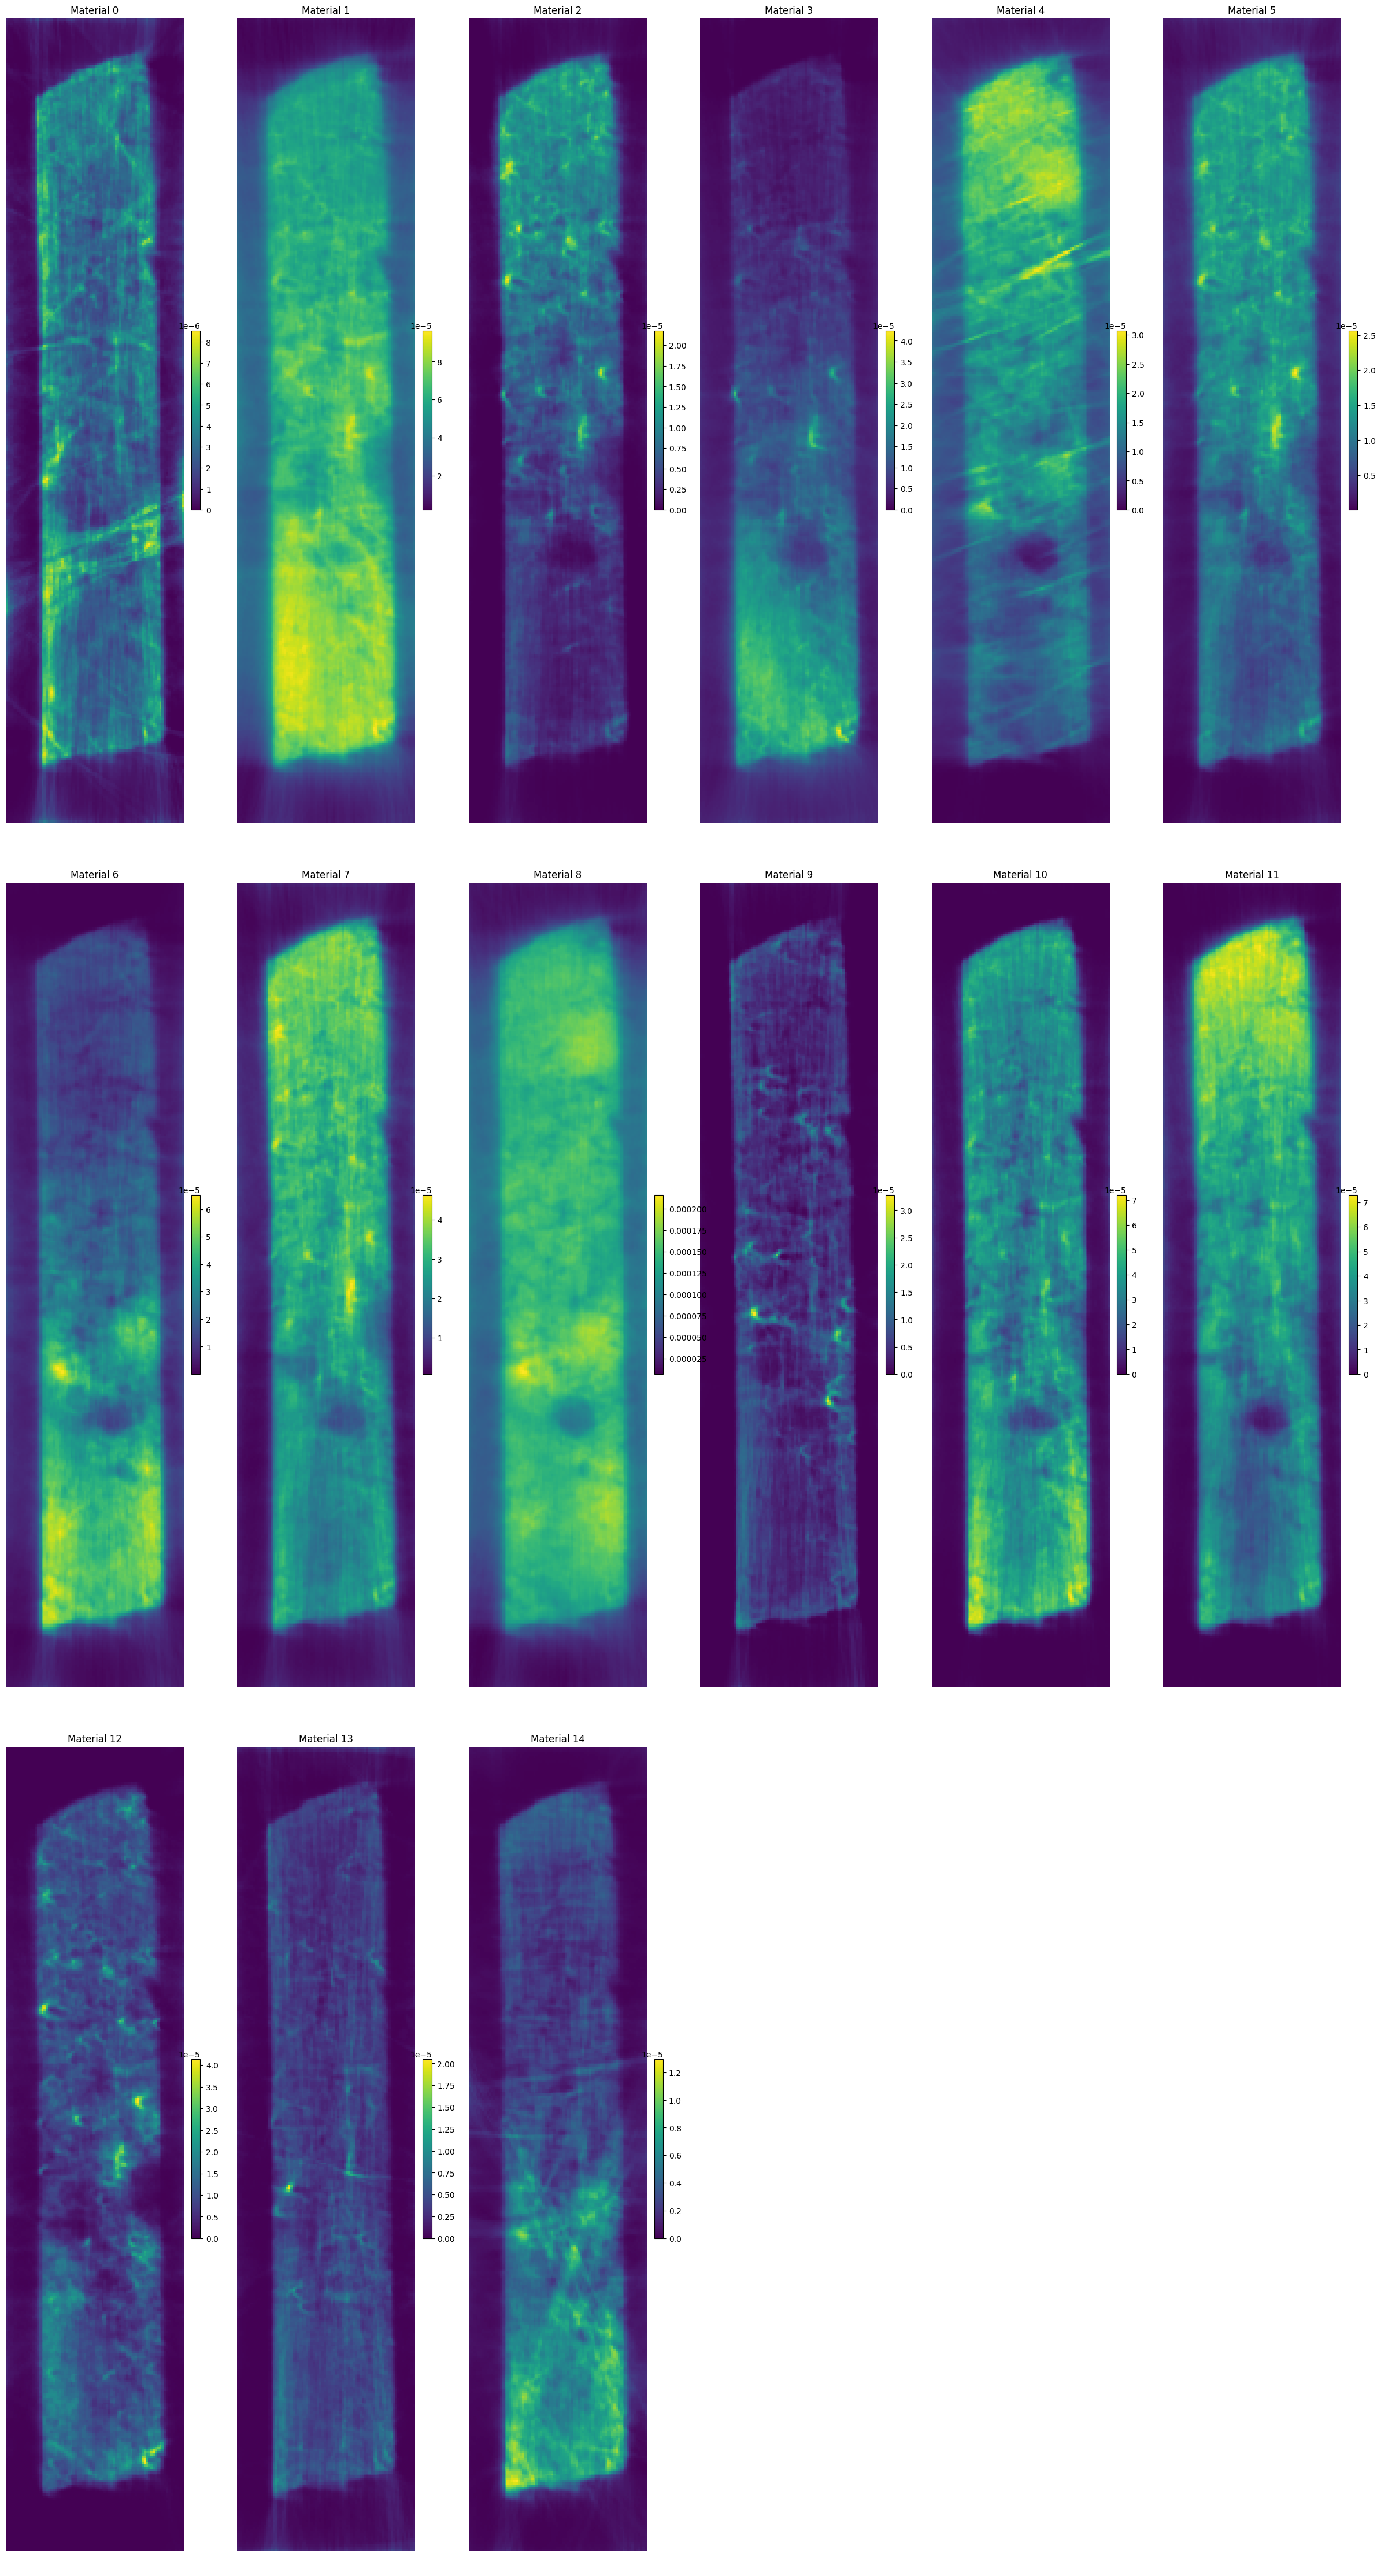

In [15]:
import math
import matplotlib.pyplot as plt

print(coeffs.shape)
print(op.K_list)

cumult_K_list = np.cumsum(
    np.concatenate([np.array([0]), np.array(op.K_list)])
)

ncols = 6
nplots = op.N_mat
nrows = math.ceil(nplots / ncols)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(4*ncols, 15*nrows),
    squeeze=False
)

for i in range(nplots):
    r = i // ncols
    c = i % ncols

    img = coeffs[:, :, cumult_K_list[i]:cumult_K_list[i+1]].sum(axis=-1)
    im = axes[r, c].imshow(img)
    axes[r, c].set_title(f"Material {i}")
    axes[r, c].axis("off")
    fig.colorbar(im, ax=axes[r, c], fraction=0.046, pad=0.04)

# hide unused axes
for i in range(nplots, nrows * ncols):
    r = i // ncols
    c = i % ncols
    axes[r, c].axis("off")

plt.tight_layout()
plt.show()
